In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import mlflow
from mlflow.models import infer_signature

In [2]:
# set the tracking
mlflow.set_tracking_uri(uri="http://localhost:5000")

In [3]:
# load the dataset
X, y = datasets.load_iris(return_X_y=True)

# split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the model hiperparameters
model_params = {
    "penalty": "l2",
    "solver": "lbfgs",
    "max_iter": 1000,
    "multi_class": "auto",
    "random_state": 42
}

# create the model
model = LogisticRegression(**model_params)

# fit the model
model.fit(X_train, y_train)


d:\Users\JSilvaZuniga\Documents\MyDocsPersonales\Cursos\NUCLIO\MLOps\Frist-app-get\MLFlow_Starter\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'auto'


In [4]:

# make predictions
y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [5]:
# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


In [6]:
# set the tracking
mlflow.set_tracking_uri(uri="http://localhost:5000")

# create a new MLFLOW Experiment
mlflow.set_experiment("MLFLOW Quickstart - Iris Classification")

# Start a new MLflow run
with mlflow.start_run() as run:

    # log the parameters and metrics
    mlflow.log_params(model_params)
    mlflow.log_metric("accuracy", accuracy)

    # set a tag that we can use to remind ourselves what this run was about
    mlflow.set_tag("Training Info", "Basic LR model on Iris dataset")

    # Infer the model signature
    signature = infer_signature(X_train, model.predict(X_train))

    # log the model with the signature
    model_info = mlflow.sklearn.log_model(
        sk_model = model,
        name = "iris_model",
        signature = signature, 
        input_example = X_train,
        registered_model_name = "Tracking-quickstart-IrisModel",
        conda_env=mlflow.sklearn.get_default_conda_env(),
        metadata={
            "dataset": "Iris",
            "author": "Jorge",
            "description": "Sklearn model trained on Iris dataset with MLflow tracking."
        }
    )

2026/06/17 21:49:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Tracking-quickstart-IrisModel' already exists. Creating a new version of this model...
2026/06/17 21:49:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Tracking-quickstart-IrisModel, version 7
Created version '7' of model 'Tracking-quickstart-IrisModel'.


🏃 View run colorful-stag-506 at: http://localhost:5000/#/experiments/2/runs/666687bc6a4c426880ad327dca03789a
🧪 View experiment at: http://localhost:5000/#/experiments/2


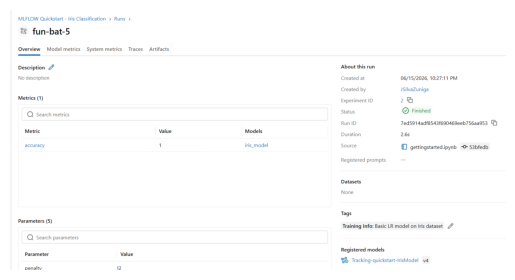

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("MLFLOW Example.png")
plt.imshow(img)
plt.axis("off")
plt.show()


In [8]:
model_info.model_uri

'models:/m-d11d1b02207c4e69926d7b093a58a59f'

# Inferencing a validating model

In [9]:
from mlflow.models import validate_serving_input

In [12]:
model_uri = model_info.model_uri

serving_input ="""{
  "inputs": [
    [
      4.6,
      3.6,
      1,
      0.2
    ],
    [
      5.7,
      4.4,
      1.5,
      0.4
    ]
  ]
}"""
validate_serving_input(model_uri=model_uri, serving_input=serving_input)

array([0, 0])

# Load the model back for prediction as a generic python function model

In [ ]:
loaded_model = mlflow.pyfunc.load_model(model_uri=model_uri)
predictions = loaded_model.predict(X_test)

iris_features = datasets.load_iris().feature_names

result = pd.DataFrame(X_test, columns=iris_features)

result["actual_class"] = y_test
result["predicted_class"] = predictions

In [17]:
result[:5]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_class,predicted_class
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1


# Model Registry

In [18]:

# create a new MLFLOW Experiment
mlflow.set_experiment("MLFLOW Quickstart - Iris Classification")

# Start a new MLflow run
with mlflow.start_run() as run:

    # log the parameters and metrics
    mlflow.log_params(model_params)
    mlflow.log_metric("accuracy", 1.0)

    # set a tag that we can use to remind ourselves what this run was about
    mlflow.set_tag("Training Info 2", "Basic LR model on Iris dataset")

    # Infer the model signature
    signature = infer_signature(X_train, model.predict(X_train))

    # log the model with the signature
    model_info = mlflow.sklearn.log_model(
        sk_model = model,
        name = "iris_model",
        signature = signature, 
        input_example = X_train,
        )

2026/06/17 22:17:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run worried-doe-901 at: http://localhost:5000/#/experiments/2/runs/7b6a1097e7684fabb1839e1ca2e4d4a9
🧪 View experiment at: http://localhost:5000/#/experiments/2


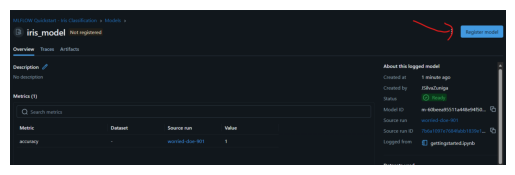

In [19]:

img = Image.open("Register Model.png")
plt.imshow(img)
plt.axis("off")
plt.show()

# Inferencing model from model registry

In [33]:
import mlflow.sklearn

model_name = "Tracking-quickstart-IrisModel"
model_version = "9"
model_uri = f"models:/{model_name}/{model_version}"

print(model_uri)


# Load by stage
# model_uri = f"models:/{model_name}@Production"

# Load latest version in a stage
# model_uri = f"models:/{model_name}@Staging"




models:/Tracking-quickstart-IrisModel/9


In [39]:
import mlflow.sklearn

model = mlflow.sklearn.load_model(model_uri)


model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'auto'


In [41]:
predictions = model.predict(X_test)

iris_features = datasets.load_iris().feature_names

result = pd.DataFrame(X_test, columns=iris_features)

result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:5]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_class,predicted_class
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1


In [35]:

mlflow.__version__


'3.13.0'